In [65]:

import os
import sys
import matplotlib.pyplot as plt

from src import loader, zdF, roi, timesync
import glob
from nre.io import load, save
import numpy as np
from tqdm import tqdm, trange
import nibabel as nib

from src.visualizations import plot_spatial_location

processed_experiment = '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001'
all_nii = glob.glob(processed_experiment + '/motion_corrected_*.nii')
print(f'Total number of volumes: {len(all_nii)}')

Total number of volumes: 2779


In [ ]:
vols_tocluster = 100

clustering based on 100 volumes


100%|██████████| 100/100 [00:37<00:00,  2.68it/s]


(512, 512, 11, 100)
extracting clusters


100%|██████████| 4/4 [10:59<00:00, 164.94s/it]


(4, 262144)
clustering based on 200 volumes


100%|██████████| 200/200 [01:18<00:00,  2.54it/s]


(512, 512, 11, 200)
extracting clusters


 25%|██▌       | 1/4 [01:14<03:44, 74.87s/it]


KeyboardInterrupt: 

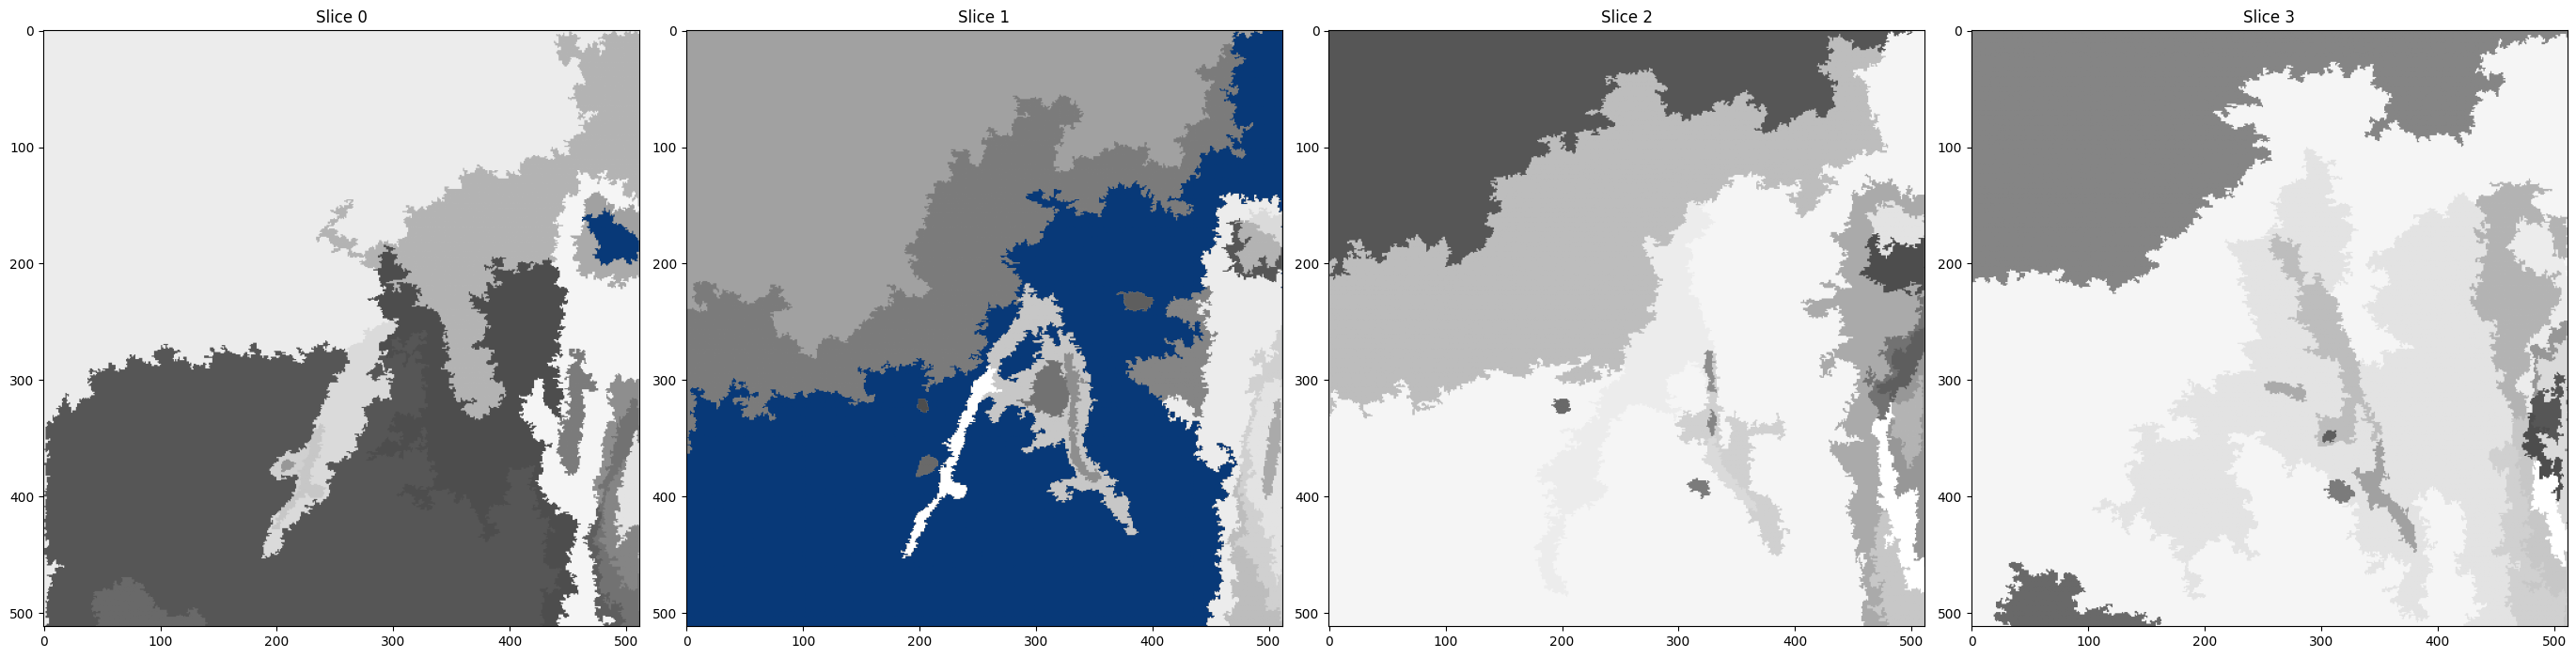

In [2]:
# determine how many volumes are needed to make 20 reliable clusters?
# 100 seems sufficient
# for a set number of volumes,
#
# n_volumes = [100,200]
# for n in n_volumes:

print(f'clustering based on {vols_tocluster} volumes')
brain_array = np.empty([512, 512, 11, vols_tocluster], dtype=np.float32)
# load each into memory mapped array
for i in trange(vols_tocluster):
    single_nii = f'{processed_experiment}/motion_corrected_volume{i}.nii'
    file = nib.load(single_nii)
    data = file.get_fdata()
    brain_array[..., i] = data
print(brain_array.shape)

brain_array = brain_array[...,6:-1,:]
# cluster into 20
n_clusters = 20
print('extracting clusters')
cluster_labels = roi.extract_ROIs(brain_array, n_clusters)
cluster_array = np.asarray(cluster_labels)
print(cluster_array.shape)

clusters_to_plot = [[0,0], [1,1]]
plot_spatial_location(clusters_to_plot, cluster_array, [brain_array.shape[0],brain_array.shape[1],brain_array.shape[2]])

print('calculating zscoredF')
df = zdF.calculate_zscoredF(
    brain = brain_array,
    labels_arr=cluster_labels,
    n_clusters=n_clusters
)

In [54]:
cluster_array.shape

(4, 262144)

In [74]:
print('getting supervoxel mean')
# slice, roi, time
# for vol in trange(len(all_nii)):
mean_signal = np.empty(shape=(cluster_array.shape[0],n_clusters,len(all_nii)))
print(mean_signal.shape)
for vol in trange(len(all_nii)):
    # load up a volume
    single_nii = f'{processed_experiment}/motion_corrected_volume{i}.nii'
    file = nib.load(single_nii)
    data = file.get_fdata()
    # remove unwanted slices
    data = data[:,:,6:-1]

    # loop over slices and get supervoxel mean
    for iSlice in range(data.shape[2]):
        mean_signal_sl = np.empty(shape=(data.shape[2], n_clusters))
        # get mean 2d value given 2d brain array, slice labels, and number of clusters
        mean_supervox, _ = roi.get_supervoxel_mean_2D(data[:, :, iSlice], cluster_array[iSlice], n_clusters)
            # assign signal at a given slice as the mean calculation
        mean_signal_sl[iSlice] = mean_supervox
        print(mean_signal_sl.shape) # t, cluster
    mean_signal[...,vol] = mean_signal_sl
print(mean_signal.shape)

getting supervoxel mean
(4, 20, 2779)


 10%|█         | 1/10 [00:00<00:03,  2.60it/s]

(4, 20)
(4, 20)
(4, 20)
(4, 20)


 20%|██        | 2/10 [00:00<00:02,  2.72it/s]

(4, 20)
(4, 20)
(4, 20)
(4, 20)


...

(4, 20)
(4, 20)
(4, 20)
(4, 20)


 90%|█████████ | 9/10 [00:03<00:00,  2.69it/s]

(4, 20)
(4, 20)
(4, 20)
(4, 20)


100%|██████████| 10/10 [00:03<00:00,  2.71it/s]

(4, 20)
(4, 20)
(4, 20)
(4, 20)
(4, 20, 2779)


(0.0, 20.0)

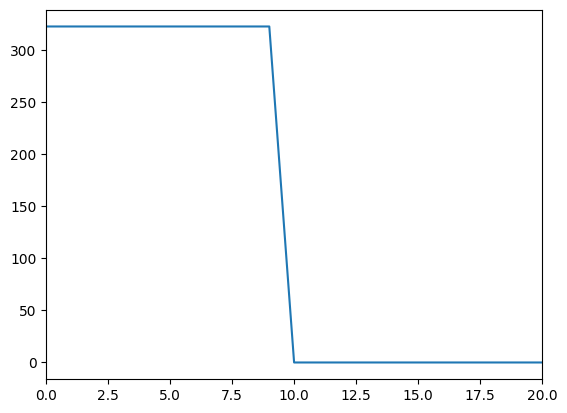

In [76]:
plt.plot(mean_signal[0,1])
plt.xlim(0,20)

In [36]:
# get mean signal of supervoxels from cluster labels
n_clusters = len(np.unique(cluster_array[-1]))

for iSlice in range(4):
    mean_signal = np.empty(shape=(1,n_clusters))
    mean_supervox, _ = roi.get_supervoxel_mean_2D(data[:,:,iSlice], cluster_array[iSlice], n_clusters)
    mean_signal = mean_supervox

print(mean_signal)

[2854.77970403  706.26201047 4890.13918297 1094.28665156 2261.43209578
 3056.40405697 3684.32490982  853.49273663 2660.66965162  881.16601844
 1014.53545581 3121.86157313 2706.77070614  267.66026851  684.19798384
 5008.59364761 1444.27164493 1441.53673803 1660.59789362 1432.61259052]


In [ ]:
print('calculating zscoredF')
df = zdF.calculate_zscoredF(
    brain = brain_array,
    labels_arr=cluster_labels,
    n_clusters=n_clusters
)

# for every

quick plots for pIP10

In [43]:
from src import visualizations
import xarray as xr
base_data_path = '/Volumes/AhmedLab/princess/data/pIP10'
experiment_id = 'pIP10_TSeries_20260427_GC8m_fly09_win02_trial-001'
processed_path = loader.get_base_path(experiment_id=experiment_id, data_stage='processed', base_dir=base_data_path)

cluster_labels, signal, timestamps = loader.load_clusters(processed_path)

In [44]:
print(signal.shape)

(11, 20, 2779)


In [ ]:
type(timestamps)

In [ ]:
signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': range(signal.shape[2])}
)
dimensions = [512, 512, 11]


In [ ]:
for z in range(10):
    to_plot = [[z, x]for x in range(signal.shape[1])]
    visualizations.plot_zscored_activity(to_plot, signal_xr)
    visualizations.plot_spatial_location(to_plot, cluster_labels, dimensions)